# Load and compare wet mode analysis

Analysis log

## Testing the consequence on the membrane case from Agarwal (2023) paper

The test case was `mfac = 0.9, tfac = 0.1`.

For this, the dry natural freqs are


| dry $\omega_n$ | wet (damped) $\omega_n$ <br> Method 1<br> Complex Mass | wet (damped) $\omega_n$ <br> New Method | 
| --- | --- | --- |
| NA | NA |
| 1.6400 + 0.0000im | 1.55445-0.273424im |
| 3.2799 + 0.0000im | 2.4142-0.204969im |
| 4.9199 + 0.0000im | 3.4685-0.153279im |










In [1]:
using Pkg
Pkg.activate("/home/shagun/Acads/HydroElasticFEM.jl")

using HydroElasticFEM

PKG_ROOT = HydroElasticFEM.PKG_ROOT

  Activating project at `~/Acads/HydroElasticFEM.jl`


"/home/shagun/Acads/HydroElasticFEM.jl/"

In [2]:
using JLD2
using Printf
using DataFrames
using Plots

In [3]:
fileName = "data/sims_202601/modes_LRHS/memb_mrho=0.90_Trho=98.10/"
fileName = fileName*"lrhs_complexMass_free_resnM=1845.00_resnK=1845.00_modesdata.jld2"
df2 = load(PKG_ROOT*fileName)

@printf("Dry Natural Frequencies :\n")
(x -> @printf("%.4f + %.4fim\n", real(x), imag(x))).(df2["dfDry"][:,"ωn"])
println()

@printf("Wet Natural Frequencies :\n")
(x -> @printf("%.4f + %.4fim\n", real(x), imag(x))).(df2["dfWet"][:,"ωn"])
println()

@printf("Wet Natural Frequencies Iterations :\n")
(x -> @printf("%d\n", x)).(df2["dfWet"][:,"iter"])
println()

nothing

┌ Warning: type Main.Memb_LRHS_params does not exist in workspace; reconstructing
└ @ JLD2 /home/shagun/.julia/packages/JLD2/SgtOb/src/data/reconstructing_datatypes.jl:588


Dry Natural Frequencies :
0.0000 + 0.0000im
1.0320 + 0.0000im
1.6400 + 0.0000im
3.3131 + 0.0000im
4.9199 + 0.0000im

Wet Natural Frequencies :
0.0000 + 0.0000im
0.9870 + -0.0060im
1.5539 + -0.2735im
2.4242 + -0.2033im
3.4675 + -0.1538im

Wet Natural Frequencies Iterations :
0
4
10
9
7



In [4]:
fileName = "data/sims_202601/modes_LRHS/memb_mrho=0.90_Trho=98.10/"
fileName = fileName*"lrhs_dampedSys_free_resnM=1845.00_resnK=1845.00_modesdata.jld2"
df_b1 = load(PKG_ROOT*fileName)

df_b1_N = size(df_b1["dfDry"][:,"V"][1], 1)

@printf("Number of dof in the second order problem: %d\n\n", df_b1_N)

@printf("Dry Natural Frequencies :\n")
(x -> @printf("%.4f + %.4fim\n", real(x), imag(x))).(df_b1["dfDry"][:,"ωn"])
println()

@printf("Wet Natural Frequencies Neg Imag :\n")
(x -> @printf("%.4f + %.4fim\n", real(x), imag(x))).(df_b1["dfWet"][:,"ωnneg"])
println()

@printf("Wet Natural Frequencies Pos Imag :\n")
(x -> @printf("%.4f + %.4fim\n", real(x), imag(x))).(df_b1["dfWet"][:,"ωnpos"])
println()

@printf("Wet Natural Frequencies Iterations :\n")
(x -> @printf("%d\n", x)).(df_b1["dfWet"][:,"iter"])
println()

nothing

Number of dof in the second order problem: 82

Dry Natural Frequencies :
0.0000 + 0.0000im
1.0320 + 0.0000im
1.6400 + 0.0000im
3.3131 + 0.0000im
4.9199 + 0.0000im

Wet Natural Frequencies Neg Imag :
0.0000 + 0.0000im


┌ Warning: type Main.Memb_LRHS_params does not exist in workspace; reconstructing
└ @ JLD2 /home/shagun/.julia/packages/JLD2/SgtOb/src/data/reconstructing_datatypes.jl:588


-0.5897 + -1.0099im
-0.2873 + -1.6151im
-0.2163 + -2.4401im
-0.1565 + -3.4744im

Wet Natural Frequencies Pos Imag :
0.0000 + 0.0000im
-0.5897 + 1.0099im
-0.2873 + 1.6151im
-0.2163 + 2.4401im
-0.1565 + 3.4744im

Wet Natural Frequencies Iterations :
0
6
8
8
6



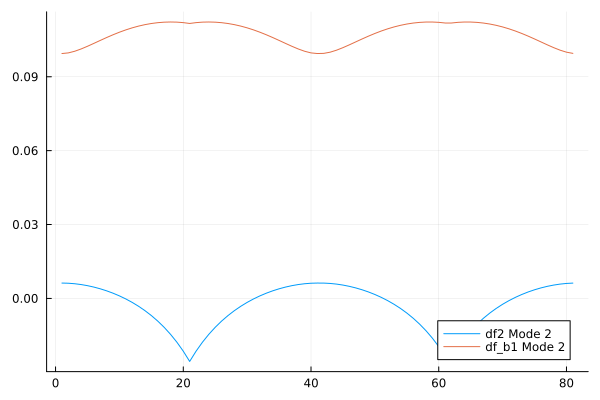

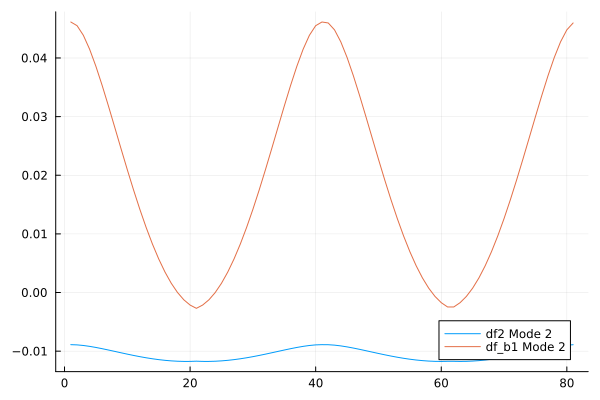

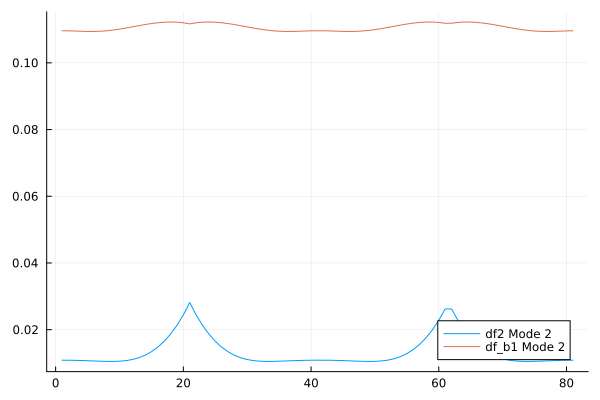

df2_V[end] = -0.9917898819515018 - 0.0im
df_b1_V[end] = 0.021887864607625415 - 0.08771520060001871im


In [7]:
# mode = 1
modeB = 2

# df1_V = df1["dfWet"][:,"V"][mode]
# df1_V = df1_V ./ sign(real(df1_V[1]))

df2_V = df2["dfWet"][:,"V"][modeB]
df2_V = df2_V ./ real(sqrt(df2_V' * df2_V))
df2_V = df2_V ./ sign(real(df2_V[1]))
@show df2_V[end]
df2_V = df2_V[1:end-1]

df_b1_V = df_b1["dfWet"][:,"Vneg"][modeB]  # Using Vneg for comparison
df_b1_V = df_b1_V[df_b1_N+1:end]  # Extract displacement part
df_b1_V = df_b1_V ./ real(sqrt(df_b1_V' * df_b1_V))
df_b1_V = df_b1_V ./ sign(real(df_b1_V[1]))
@show df_b1_V[end]
df_b1_V = df_b1_V[1:end-1]

# df_b1_V = df_b1["dfDry"][:,"V"][modeB]  # Using Vneg for comparison
# df_b1_V = df_b1_V ./ real(sqrt(df_b1_V' * df_b1_V))
# df_b1_V = df_b1_V ./ sign(real(df_b1_V[1]))
# @show df_b1_V[end]
# df_b1_V = df_b1_V[1:end-1]


plot()
# plot!(real(df1_V), label="df1 Mode $mode")
plot!(real(df2_V), label="df2 Mode $modeB")
plot!(real(df_b1_V), label="df_b1 Mode $modeB")
plot!(legend=:bottomright)
display(plot!())

plot()
# plot!(imag(df1_V), label="df1 Mode $mode")
plot!(imag(df2_V), label="df2 Mode $modeB")
plot!(imag(df_b1_V), label="df_b1 Mode $modeB")
plot!(legend=:bottomright)
display(plot!())


plot()
# plot!(abs.(df1_V), label="df1 Mode $mode")
plot!(abs.(df2_V), label="df2 Mode $modeB")
plot!(abs.(df_b1_V), label="df_b1 Mode $modeB")
plot!(legend=:bottomright)
display(plot!())
